<a href="https://colab.research.google.com/github/GalardOnly/GalardOnly/blob/main/Regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from numpy import *

class LinearRegression:  #Classe que implementa Regressão Linear Simples
  def __init__(self, x, y): # Construtor que recebe os dados de entrada (x) e saída (y)
    self.x = x
    self.y = y
    self.__correlation_coefficientent = self.__correlacao() #  Calcula o coeficiente de correlação
    self.__inclination = self.__inclinacao() #  Calcula o coeficiente angular (inclinação da reta)
    self.__intercept = self.__interceptacao() # Calcula o intercepto (ponto onde a reta cruza o eixo Y)

  def __correlacao(self): # Método privado para calcular a correlação entre x e y
    covariacao = cov(self.x, self.y, bias=True)[0][1] #bias=True = usa a versão com viés (divisão por N, não N-1)
    # bias=True → Covariância populacional (divide por N, usado quando temos todos os dados)
    # bias=False → Covariância amostral (divide por N-1, melhor para estimar a população a partir de uma amostra)
    variancia_x = var(self.x)
    variancia_y = var(self.y)
    return covariacao / sqrt(variancia_x * variancia_y)


  def __inclinacao(self):
    stdx = std(self.x)
    stdy = std(self.y)
    return self.__correlation_coefficientent * (stdy / stdx) # Fórmula da inclinação (b = r * (std_y / std_x))

  def __interceptacao(self):

    mediax = mean(self.x)
    mediay = mean(self.y)
    return mediay - mediax + self.__inclination




  def previsao(self,valor):
    return self.__intercept + (self.__inclination * valor)  # Equação da reta: y = b + mx




In [ ]:
x = array ([1,2,3,4,5])
y = array([2,4,6,8,10])

lr = LinearRegression(x,y)
previsao = lr.previsao(6)
print(previsao)

17.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
import scipy.stats as stats
import seaborn as sns

In [ ]:
base = pd.read_csv('mt_cars.csv')
base.shape

(32, 12)

In [ ]:
base.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [ ]:
base = base.drop(['Unnamed: 0'], axis=1) #aqui nós removemos a primeira coloca com os nomes do carro pois nao é necessario(por enquanto)

KeyError: "['Unnamed: 0'] not found in axis"

<Axes: >

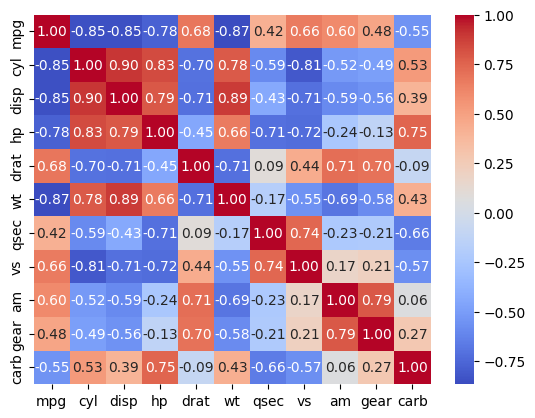

In [ ]:
corr = base.corr() #aqui fazemos a correlação em forma de mapa de calor
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
#annot gera os valores em cada celular, false nao mostra, o contrario....

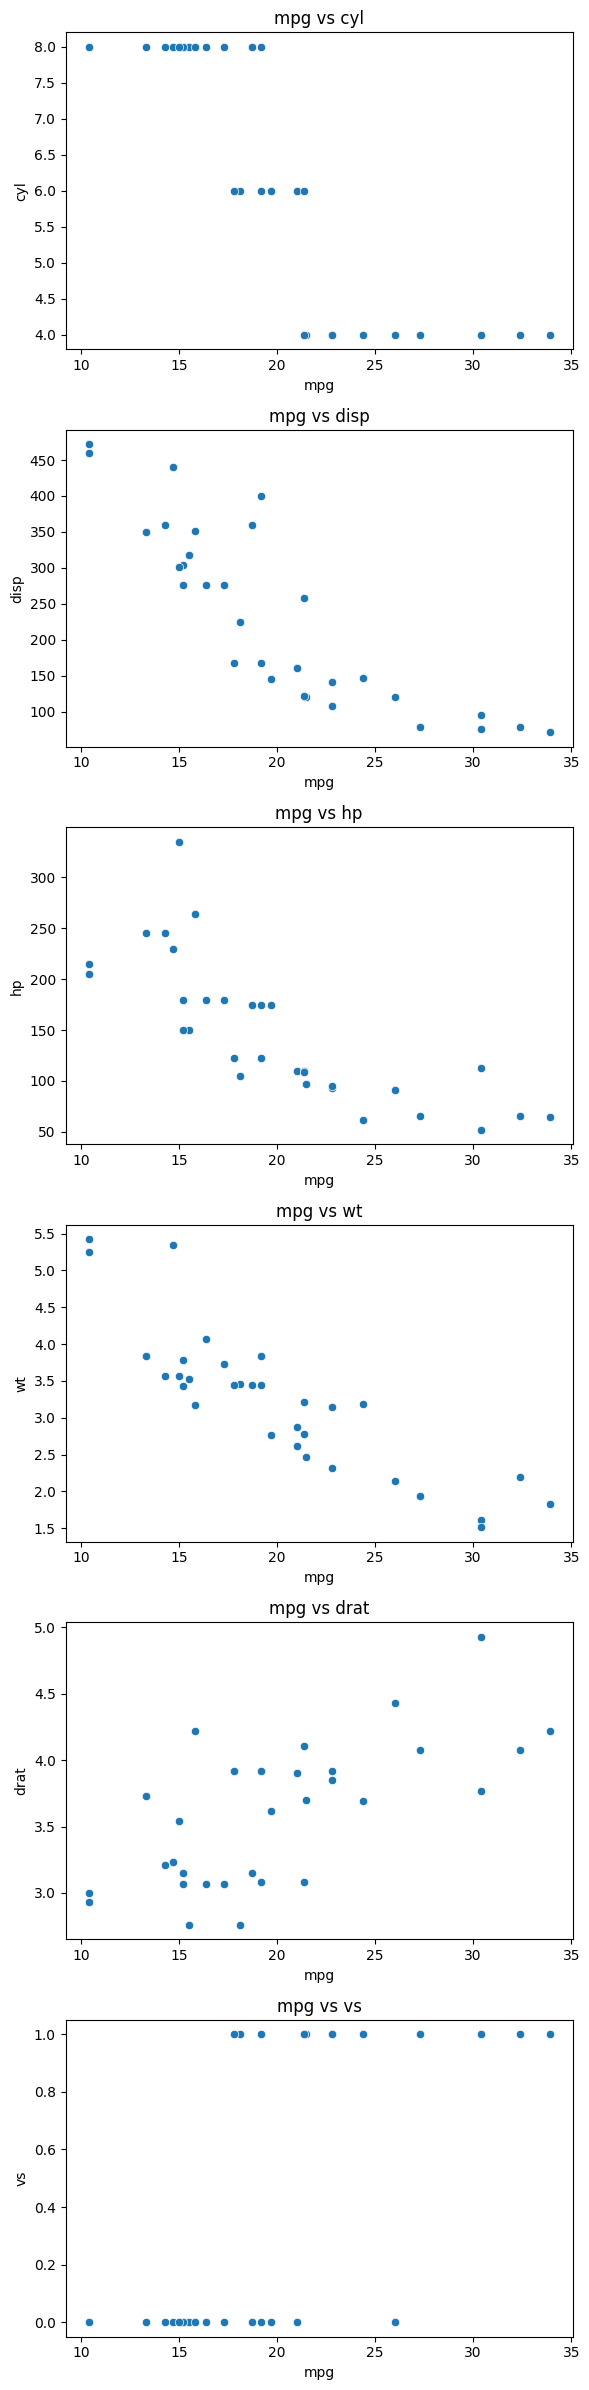

In [ ]:
column_pairs = [('mpg','cyl'),('mpg','disp'),('mpg','hp'),('mpg','wt'),('mpg','drat'),('mpg','vs')]
n_plots = len(column_pairs)
fig, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(6,4 * n_plots))
# Cria uma figura com múltiplos subgráficos (um para cada par de colunas)
#figsize=(6, 4 * n_plots) → Define o tamanho da figura proporcional ao número de gráficos

for i, pair in enumerate(column_pairs):
  x_col, y_col = pair # Desempacota os nomes das colunas x e y
  sns.scatterplot(x=x_col, y=y_col, data=base, ax=axes[i])
  # Cria um gráfico de dispersão para o par de colunas atual
  axes[i].set_title(f'{x_col} vs {y_col}')

  plt.tight_layout()
  plt.show

In [ ]:
#aic 156.6, bic 162.5
#modelo = sm.ols(formula='mpg ~ wt + disp + hp',data=base)

# aic 165.1 bic 169.5 ficaram maiores
#modelo = sm.ols(formula='mpg ~  disp + cyl',data=base)

#aic 179.1 bic 183.5
modelo = sm.ols(formula='mpg ~  drat + vs',data=base)
modelo = modelo.fit()
modelo.summary() # tras alguns dados estatisticos

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     24.53
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           5.82e-07
Time:                        22:25:58   Log-Likelihood:                -86.536
No. Observations:                  32   AIC:                             179.1
Df Residuals:                      29   BIC:                             183.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8253      4.903     -0.372      0.712     -11.853       8.202
drat           5.4365      1.421      3.826      0.001       2.530       8.343
vs             5.4013      1.507      3.583      0.001       2.318       8.484
==============================================================================
Omnibus:                        0.243   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.886   Jarque-Bera (JB):                0.440
Skew:                           0.059   Prob(JB):                        0.803
Kurtosis:                       2.438   Cond. No.                         29.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<function matplotlib.pyplot.show(close=None, block=None)>

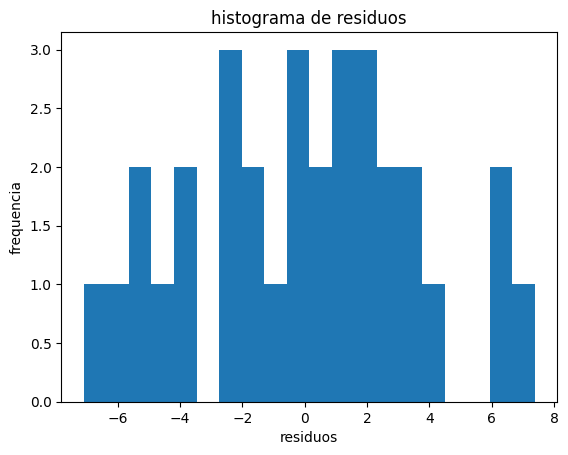

In [ ]:
#pegaremos os residuais do modelo acima

residuos = modelo.resid
plt.hist(residuos, bins=20)
plt.xlabel('residuos')
plt.ylabel('frequencia')
plt.title('histograma de residuos')
plt.show

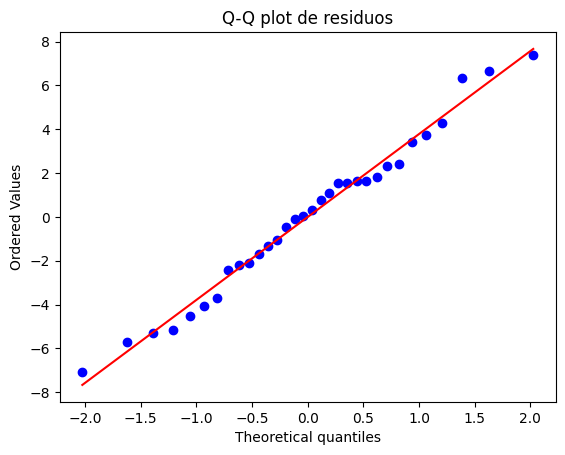

In [ ]:
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q plot de residuos")
plt.show()

In [ ]:
# hipotese nula = 0, dados estão normalmente distribuidos
# p <= 0.05 rejeito a hipotese nula, ( nao estao normalmente distruidos)
#p > 0.05 nao é possivel rejeitar a hipotese nula
#nesse caso temos indicios que os graficos estao certamente distribuidos
stat, pval = stats.shapiro(residuos)
print(f'shapiro-wilk statistica: {stat:.3f}, p-value: {pval:.3f}' )

shapiro-wilk statistica: 0.981, p-value: 0.822
